In [16]:
import tensorflow as tf
import keras

print(tf.__version__)
print(keras.__version__)

2.16.2
3.15.1


In [17]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.optimizers import Adam

file = "Datasets/train/images_datasets"
class_names = ['airplanes', 'buses', 'cars', 'motorcycles', 'ship']
num_classes = len(class_names)

image_generator = keras.preprocessing.image.ImageDataGenerator(validation_split=0.2,
                                                                horizontal_flip=True,
                                                                rotation_range=20,
                                                                width_shift_range=0.2,
                                                                height_shift_range=0.2,
                                                                zoom_range=0.2,
                                                                shear_range=0.2,
                                                                fill_mode='nearest')
train_data_gen=image_generator.flow_from_directory(directory=file,
                                                   target_size=(256,256),
                                                   batch_size=12,
                                                   class_mode='categorical',
                                                   classes=class_names,
                                                   subset='training')
val_data_gen=image_generator.flow_from_directory(directory=file,
                                                 target_size=(256,256),
                                                 batch_size=12,
                                                 class_mode='categorical',
                                                 classes=class_names,
                                                 subset='validation')



Found 400 images belonging to 5 classes.
Found 100 images belonging to 5 classes.


In [18]:
model = keras.models.Sequential([
    keras.Input(shape=(256, 256, 3)),
    keras.layers.Conv2D(32, (3, 3), strides=(1, 1), activation='relu'),
    keras.layers.MaxPooling2D((2, 2)),

    keras.layers.Conv2D(64, (3, 3), strides=(1, 1), activation='relu'),
    keras.layers.MaxPooling2D((2, 2)),

    keras.layers.Conv2D(128, (3, 3), strides=(1, 1), activation='relu'),
    keras.layers.MaxPooling2D((2, 2)),

    keras.layers.Flatten(),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(num_classes, activation='softmax')
])
adam_optimizer = Adam(learning_rate=0.0001)
model.compile(optimizer=adam_optimizer, loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()
#early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
history=model.fit(train_data_gen, validation_data=val_data_gen,  epochs=20, verbose=2)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │    14,745,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,839,621 (56.61 MB)

 Trainable params: 14,839,621 (56.61 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
34/34 - 5s - 150ms/step - accuracy: 0.2150 - loss: 174.3154 - val_accuracy: 0.2500 - val_loss: 16.3155
Epoch 2/20
34/34 - 4s - 112ms/step - accuracy: 0.3200 - loss: 10.9439 - val_accuracy: 0.4200 - val_loss: 7.3904
Epoch 3/20
34/34 - 4s - 112ms/step - accuracy: 0.4175 - loss: 5.1647 - val_accuracy: 0.4000 - val_loss: 5.1518
Epoch 4/20
34/34 - 4s - 119ms/step - accuracy: 0.4175 - loss: 5.3596 - val_accuracy: 0.3700 - val_loss: 4.7347
Epoch 5/20
34/34 - 4s - 115ms/step - accuracy: 0.4375 - loss: 4.1421 - val_accuracy: 0.4400 - val_loss: 4.0477
Epoch 6/20
34/34 - 4s - 114ms/step - accuracy: 0.4500 - loss: 3.4618 - val_accuracy: 0.4000 - val_loss: 4.0951
Epoch 7/20
34/34 - 4s - 114ms/step - accuracy: 0.4800 - loss: 2.7343 - val_accuracy: 0.4800 - val_loss: 4.7174
Epoch 8/20
34/34 - 4s - 114ms/step - accuracy: 0.4675 - loss: 3.5177 - val_accuracy: 0.4400 - val_loss: 3.7090
Epoch 9/20
34/34 - 4s - 114ms/step - accuracy: 0.4900 - loss: 3.1584 - val_accuracy: 0.4700 - val_loss: 3.87

In [19]:
model.save('model.h5')
print("Model saved as 'model.h5'")

# Get class labels from the training generator
class_labels = list(train_data_gen.class_indices.keys())
print("Class labels:", class_labels)

Model saved as 'model.h5'
Class labels: ['airplanes', 'buses', 'cars', 'motorcycles', 'ship']


In [23]:
import numpy as np
from tensorflow import keras
from sklearn.metrics import precision_recall_fscore_support, accuracy_score
import os

test_dir = "Datasets/test/"


model_path = "model.h5"

img_height = 256
img_width = 256
batch_size = 32

try:
    model = keras.models.load_model(model_path, compile=False)
    print("Model loaded successfully!")
except Exception as e:
    print(f"Error loading model: {e}")
    exit()

# Create a data generator for the test data
test_datagen = keras.preprocessing.image.ImageDataGenerator()
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical',
    classes=class_names,
    shuffle=False
)

true_classes = test_generator.classes
class_labels = class_names

# Make predictions
predictions = model.predict(test_generator)
predicted_classes = np.argmax(predictions, axis=1)

# --- Calculate Metrics ---
accuracy = accuracy_score(true_classes, predicted_classes)
precision, recall, f1, support = precision_recall_fscore_support(true_classes, predicted_classes, average=None, labels=range(len(class_labels)))

print("\nPer-class metrics:")
print(f"{'Class':<12} {'Prec%':<8} {'Rec%':<8} {'F1%':<8} {'Support'}")
print("-" * 50)

for i, label in enumerate(class_labels):
    print(f"{label:<12} {precision[i]*100:<8.2f} {recall[i]*100:<8.2f} {f1[i]*100:<8.2f} {support[i]}")

print("\nMacro:")
print(f"Accuracy:         {accuracy*100:.2f}%")
print(f"Precision(macro): {np.mean(precision)*100:.2f}%")
print(f"Recall(macro):    {np.mean(recall)*100:.2f}%")
print(f"F1(macro):        {np.mean(f1)*100:.2f}%")

Model loaded successfully!
Found 101 images belonging to 5 classes.
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 125ms/step

Per-class metrics:
Class        Prec%    Rec%     F1%      Support
--------------------------------------------------
airplanes    85.71    57.14    68.57    21
buses        54.55    60.00    57.14    20
cars         66.67    90.00    76.60    20
motorcycles  58.06    90.00    70.59    20
ship         85.71    30.00    44.44    20

Macro:
Accuracy:         65.35%
Precision(macro): 70.14%
Recall(macro):    65.43%
F1(macro):        63.47%


In [21]:
import numpy as np
from tensorflow import keras

#img_path = "Testcases/test/airplanes/airplane1.jpg"

#img_path = "Testcases/test/cars/cars1.jpg"

img_path = "Datasets/test/ship/ship_001.jpg"

#img_path = "Testcases/test/airplanes/airplane1.jpg"

img = keras.preprocessing.image.load_img(img_path, target_size=(256, 256))
img_array = keras.preprocessing.image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

predictions = model.predict(img_array)
predicted_class = np.argmax(predictions[0])
confidence = predictions[0][predicted_class]

print(f"Predicted class: {class_labels[predicted_class]}")
print(f"Confidence: {confidence:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
Predicted class: buses
Confidence: 0.5258


Model loaded successfully!


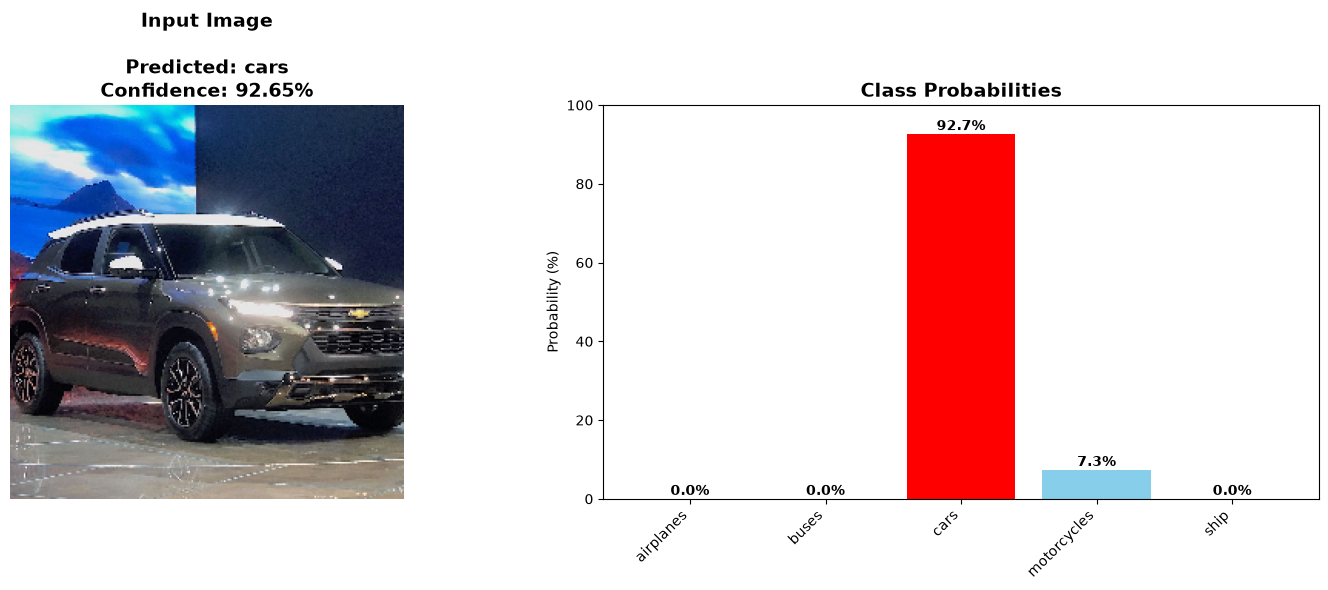


PREDICTION RESULTS
Image: cars12.jpg
Predicted class: cars
Confidence: 92.65%

All class probabilities:
   airplanes   : 0.00%
   buses       : 0.00%
👉 cars        : 92.65%
   motorcycles : 7.34%
   ship        : 0.00%


In [26]:
import os
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras

CLASS_NAMES = [
    "airplanes",
    "buses",
    "cars",
    "motorcycles",
    "ship",
]


def test_single_image(img_path, model_path="model.h5"):
    """Test one image and display the prediction results."""

    if not os.path.exists(img_path):
        print(f"Image file not found: {img_path}")
        return

    if not os.path.exists(model_path):
        print(f"Model file not found: {model_path}")
        return

    try:
        model = keras.models.load_model(model_path, compile=False)
        print("Model loaded successfully!")
    except Exception as error:
        print(f"Error loading model: {error}")
        return

    # Confirm that the model matches the five new classes.
    if model.output_shape[-1] != len(CLASS_NAMES):
        print(
            f"Model has {model.output_shape[-1]} outputs, "
            f"but {len(CLASS_NAMES)} classes are configured. "
            "Please retrain and save the model."
        )
        return

    try:
        image = keras.utils.load_img(
            img_path,
            target_size=(256, 256),
        )
        image_array = keras.utils.img_to_array(image)
        image_batch = np.expand_dims(image_array, axis=0)
    except Exception as error:
        print(f"Error processing image: {error}")
        return

    probabilities = model.predict(image_batch, verbose=0)[0]
    predicted_index = int(np.argmax(probabilities))
    predicted_class = CLASS_NAMES[predicted_index]
    confidence = float(probabilities[predicted_index])

    plt.figure(figsize=(15, 6))

    plt.subplot(1, 2, 1)
    plt.imshow(image)
    plt.title(
        f"Input Image\n\n"
        f"Predicted: {predicted_class}\n"
        f"Confidence: {confidence:.2%}",
        fontsize=14,
        fontweight="bold",
    )
    plt.axis("off")

    plt.subplot(1, 2, 2)
    colors = [
        "red" if index == predicted_index else "skyblue"
        for index in range(len(CLASS_NAMES))
    ]

    bars = plt.bar(
        CLASS_NAMES,
        probabilities * 100,
        color=colors,
    )

    plt.title("Class Probabilities", fontsize=14, fontweight="bold")
    plt.ylabel("Probability (%)")
    plt.ylim(0, 100)
    plt.xticks(rotation=45, ha="right")

    for bar, probability in zip(bars, probabilities):
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 1,
            f"{probability * 100:.1f}%",
            ha="center",
            fontweight="bold",
        )

    plt.tight_layout()
    plt.show()

    print("\n" + "=" * 50)
    print("PREDICTION RESULTS")
    print("=" * 50)
    print(f"Image: {os.path.basename(img_path)}")
    print(f"Predicted class: {predicted_class}")
    print(f"Confidence: {confidence:.2%}")
    print("\nAll class probabilities:")

    for index, (label, probability) in enumerate(
        zip(CLASS_NAMES, probabilities)
    ):
        marker = "👉" if index == predicted_index else "  "
        print(f"{marker} {label:<12}: {probability:.2%}")

    print("=" * 50)


if __name__ == "__main__":
    image_path = "Datasets/test/cars/cars12.jpg"
    test_single_image(image_path)